# 1. Análise Analítica de Cavidade Ressonante Elíptica 3D (Modos TE e TM)

Este notebook calcula os parâmetros fundamentais de uma cavidade ressonante elíptica 3D, estrutura essencial na otimização de dispositivos de alta complexidade e precisão, como MASERs de estado sólido em temperatura ambiente. A geometria exige a mudança do sistema de coordenadas cartesianas para o sistema de coordenadas elípticas $(\xi, \eta, z)$.

A elipse base é definida pelo semi-eixo maior ($a$) e semi-eixo menor ($b$), estendida por um comprimento longitudinal ($d$). A distância focal $f$ é dada por $f = \sqrt{a^2 - b^2}$. A fronteira metálica ocorre na coordenada radial elíptica constante $\xi_0 = \text{acosh}(a/f)$ e nas extremidades $z = 0$ e $z = d$.

## 1.1 Frequências de Ressonância e Funções de Mathieu

As equações de onda na cavidade resultam nas **Funções de Mathieu** e em ondas estacionárias ao longo do eixo $z$. Os modos pares são denotados como $eTE_{mnp}$ e $eTM_{mnp}$:
* **$m$**: Ordem da função angular de Mathieu (variações azimutais).
* **$n$**: Índice da raiz da função radial modificada de Mathieu.
* **$p$**: Número de meias-ondas ao longo do comprimento da cavidade ($z$).

A componente transversal do número de onda ($k_c$) é governada pelo parâmetro estrutural $q = \left(\frac{k_c f}{2}\right)^2$. A raiz numérica deve garantir que:
* **Modos TM:** $Ce_m(\xi_0, q) = 0$
* **Modos TE:** $Ce'_m(\xi_0, q) = 0$

A frequência de ressonância tridimensional final é calculada associando o número de onda transversal $k_c$ e o número de onda longitudinal $k_z = \frac{p \pi}{d}$:
$$f_{mnp} = \frac{c}{2 \pi \sqrt{\epsilon_r}} \sqrt{k_c^2 + \left(\frac{p \pi}{d}\right)^2}$$

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp
import scipy.optimize as opt
from mpl_toolkits.mplot3d import Axes3D

class CavidadeEliptica3D:
    def __init__(self, a, b, d, er=1.0):
        """
        Inicializa a cavidade elíptica 3D.
        a: Semi-eixo maior (em x)
        b: Semi-eixo menor (em y)
        d: Comprimento da cavidade (em z)
        """
        if b >= a:
            raise ValueError("O semi-eixo 'a' (x) deve ser estritamente maior que 'b' (y).")
            
        self.a = a
        self.b = b
        self.d = d
        self.er = er
        self.c = sc.c / np.sqrt(er)
        
        # Parâmetros focais da elipse
        self.f = np.sqrt(a**2 - b**2)
        self.xi_0 = np.arccosh(a / self.f)
        
    def _equacao_raizes(self, kc, m, tipo_modo):
        """Equação cujo zero determina o kc. Usa as funções de Mathieu."""
        q = (kc * self.f / 2)**2
        
        # sp.mathieu_modcem1 retorna: (valor_da_funcao, valor_da_derivada)
        ce_val, ce_der = sp.mathieu_modcem1(m, q, self.xi_0)
        
        if tipo_modo.upper() == 'TM':
            return ce_val  # TM exige que a função seja 0 na borda
        elif tipo_modo.upper() == 'TE':
            return ce_der  # TE exige que a derivada seja 0 na borda
        else:
            raise ValueError("Tipo deve ser 'TE' ou 'TM'")

    def k_c(self, m, n, tipo_modo):
        """Busca a n-ésima raiz da função de Mathieu para encontrar kc transversal."""
        # Chute inicial baseado em um círculo equivalente
        r_eq = (self.a + self.b) / 2.0
        kc_guess = sp.jn_zeros(m, n)[n-1] / r_eq if tipo_modo == 'TM' else sp.jnp_zeros(m, n)[n-1] / r_eq
        
        # Criamos um vetor de busca para "enlaçar" a raiz corretamente
        kcs = np.linspace(kc_guess * 0.5, kc_guess * 2.0, 500)
        valores = [self._equacao_raizes(k, m, tipo_modo) for k in kcs]
        
        # Detecta mudanças de sinal (onde a raiz cruza o zero)
        mudancas_sinal = np.where(np.diff(np.sign(valores)))[0]
        
        if len(mudancas_sinal) < n:
            raise RuntimeError("Não foi possível encontrar a raiz com a precisão atual.")
            
        idx_raiz = mudancas_sinal[n-1]
        
        # Refina a raiz encontrada usando o algoritmo de Brent
        kc_otimizado = opt.brentq(self._equacao_raizes, kcs[idx_raiz], kcs[idx_raiz+1], args=(m, tipo_modo))
        
        return kc_otimizado

    def freq_ressonancia(self, m, n, p, tipo_modo):
        """Frequência de ressonância 3D analítica para o modo eTE ou eTM."""
        kc = self.k_c(m, n, tipo_modo)
        kz = (p * np.pi) / self.d
        k_total = np.sqrt(kc**2 + kz**2)
        return (self.c / (2 * np.pi)) * k_total

print("Classe CavidadeEliptica3D (com funções de Mathieu e Solvers) carregada!")

Classe CavidadeEliptica3D (com funções de Mathieu e Solvers) carregada!


## 1.2 Distribuição do Campo na Cavidade

A distribuição espacial tridimensional dos modos pares (Even) depende das funções angulares e radiais modificadas de Mathieu, ponderadas pelas ondas estacionárias no comprimento $d$.

* **Modos eTM ($H_z = 0$)**: O campo elétrico longitudinal reflete um padrão cossenoidal/senoidal.
$$E_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q) \cdot \cos\left(\frac{p \pi z}{d}\right)$$
* **Modos eTE ($E_z = 0$)**: O campo magnético longitudinal reflete a modulação estacionária correspondente.
$$H_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q) \cdot \sin\left(\frac{p \pi z}{d}\right)$$

In [27]:
def plotar_cavidade_3d_fatias(cavidade, tipo_modo, m=0, n=1, p=1, fatias_z=5):
    """
    Renderiza fatias (slices) do volume 3D da cavidade para visualizar
    os máximos e mínimos do campo eletromagnético.
    """
    a, b, d, f = cavidade.a, cavidade.b, cavidade.d, cavidade.f
    
    x = np.linspace(-a, a, 100)
    y = np.linspace(-b, b, 100)
    X, Y = np.meshgrid(x, y)
    
    # Máscara cartesiana para restringir à elipse
    mask = (X**2 / a**2) + (Y**2 / b**2) <= 1
    
    # Complex math trick para coordenadas elípticas
    Z_complex = (X[mask] + 1j * Y[mask]) / f
    xi_eta = np.arccosh(Z_complex)
    xi = np.real(xi_eta)
    eta = np.imag(xi_eta)
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    try:
        kc = cavidade.k_c(m, n, tipo_modo)
        q = (kc * f / 2)**2
        f_res = cavidade.freq_ressonancia(m, n, p, tipo_modo)
        
        # Componente Transversal (Mathieu)
        Ce_m = np.array([sp.mathieu_modcem1(m, q, xi_val)[0] for xi_val in xi])
        ce_m = np.array([sp.mathieu_cem(m, q, eta_val * 180 / np.pi)[0] for eta_val in eta])
        campo_transversal = Ce_m * ce_m
        
    except Exception as e:
        print(f"Não foi possível calcular o modo {tipo_modo}_{m}{n}{p}: {e}")
        return
        
    z_vals = np.linspace(0, d, fatias_z)
    kz = (p * np.pi) / d
    max_campo = 0
    fatias_dados = []
    
    for z_val in z_vals:
        # Variação em Z da onda estacionária
        modulacao_z = np.cos(kz * z_val) if tipo_modo.upper() == 'TM' else np.sin(kz * z_val)
        campo_z = campo_transversal * modulacao_z
        campo_abs = np.abs(campo_z)
        
        if np.max(campo_abs) > max_campo:
            max_campo = np.max(campo_abs)
            
        Z_plot = np.full_like(X, np.nan)
        Z_plot[mask] = campo_abs
        fatias_dados.append((z_val, Z_plot))

    niveis_cor = np.linspace(0, 1, 21)
    
    for z_val, Z_plot in fatias_dados:
        # Normalização usando o máximo global da cavidade
        Z_norm = Z_plot / max_campo if max_campo > 0 else Z_plot
        cf = ax.contourf(X, Y, Z_norm, zdir='z', offset=z_val, levels=niveis_cor, cmap='jet', alpha=0.8)
        
        # Bordas metálicas na visualização
        elipse_borda_x = a * np.cos(np.linspace(0, 2*np.pi, 100))
        elipse_borda_y = b * np.sin(np.linspace(0, 2*np.pi, 100))
        ax.plot(elipse_borda_x, elipse_borda_y, z_val, color='black', lw=1.5)

    ax.set_title(f"Cavidade Elíptica 3D - Modo e{tipo_modo}_{m}{n}{p}\nFreq. de Ressonância: {f_res/1e9:.4f} GHz", fontsize=14)
    ax.set_xlabel('Eixo X (m)')
    ax.set_ylabel('Eixo Y (m)')
    ax.set_zlabel('Eixo Z (m)')
    ax.set_xlim(-a, a)
    ax.set_ylim(-b, b)
    ax.set_zlim(0, d)
    
    # Ajuste de perspectiva
    ax.set_box_aspect((1, b/a, d/(2*a)))
    fig.colorbar(cf, ax=ax, shrink=0.5, aspect=10, label='Amplitude Normalizada')
    
    plt.tight_layout()
    plt.show()

## 1.3 Execução e Visualização
Abaixo, instanciamos a estrutura passando suas três dimensões (semi-eixos e profundidade) e escolhemos o modo desejado para calcular a frequência de ressonância e visualizar o comportamento 3D dos campos.

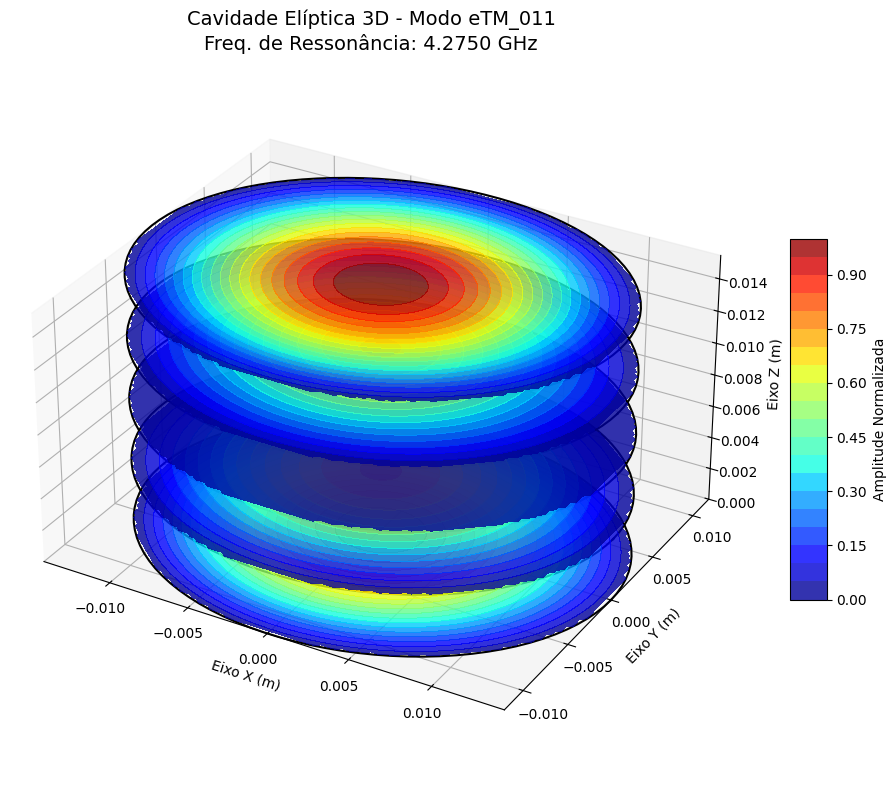

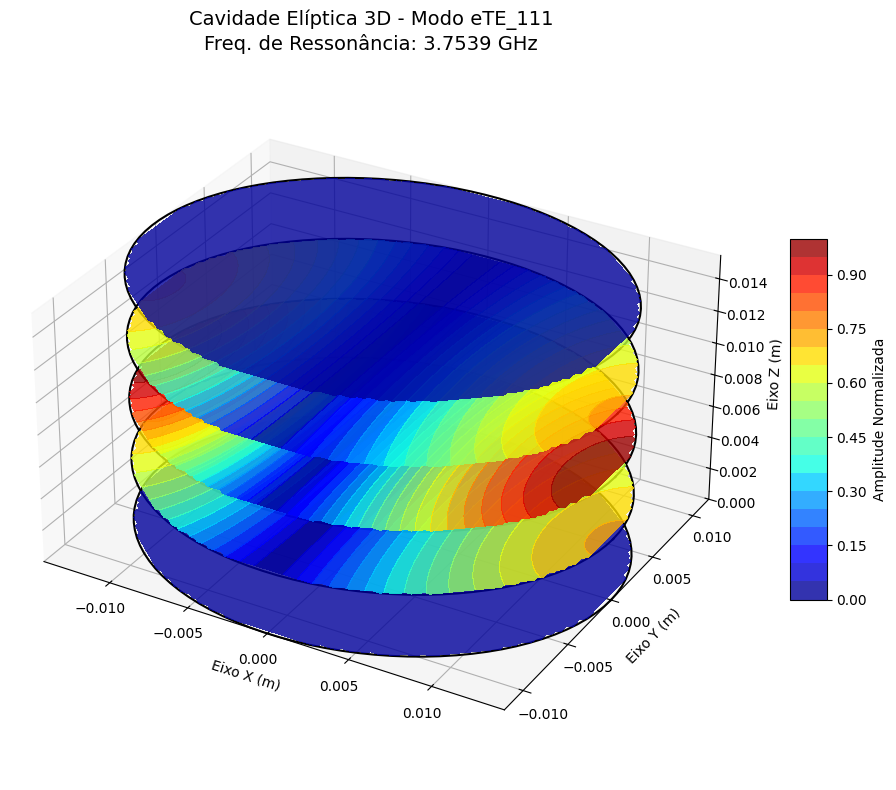

In [28]:
# 1. Definições da Cavidade Elíptica (Valores baseados na tabela)
# Utilizando scipy.constants.milli para a conversão direta das unidades
a_mm = 14.30  # a (semi-major)
b_mm = 12.04  # b (semi-minor)
d_mm = 15.44   # L (height / comprimento longitudinal)
er_val = 9.4  # Air cavity (epsilon_r = 9.4)

# Instanciando a cavidade com as novas medidas em milímetros
cavidade_elip = CavidadeEliptica3D(a=a_mm * sc.milli, b=b_mm * sc.milli, d=d_mm * sc.milli, er=er_val)

# 2. Renderizando as fatias de campo na cavidade (Pode demorar uns segundos devido ao solver)
# Exemplo 1: Modo eTM_011
plotar_cavidade_3d_fatias(cavidade_elip, tipo_modo='TM', m=0, n=1, p=1, fatias_z=5)

# Exemplo 2: Modo eTE_111
plotar_cavidade_3d_fatias(cavidade_elip, tipo_modo='TE', m=1, n=1, p=1, fatias_z=5)

## 1.4 Resposta em S₁₁ (Fator de Qualidade e Acoplamento Analíticos)

Para traçar a curva de reflexão realística, calculamos o Fator de Qualidade Descarregado ($Q_0$) analiticamente, assumindo as perdas nas paredes metálicas (efeito pelicular). 

A profundidade e a largura da ressonância no espectro dependem do **Fator de Acoplamento ($\beta$)** da sonda que excita a cavidade. Utilizamos a equação exata da reflexão $|\Gamma(f)|$ de um ressoador de micro-ondas para plotar o S₁₁.

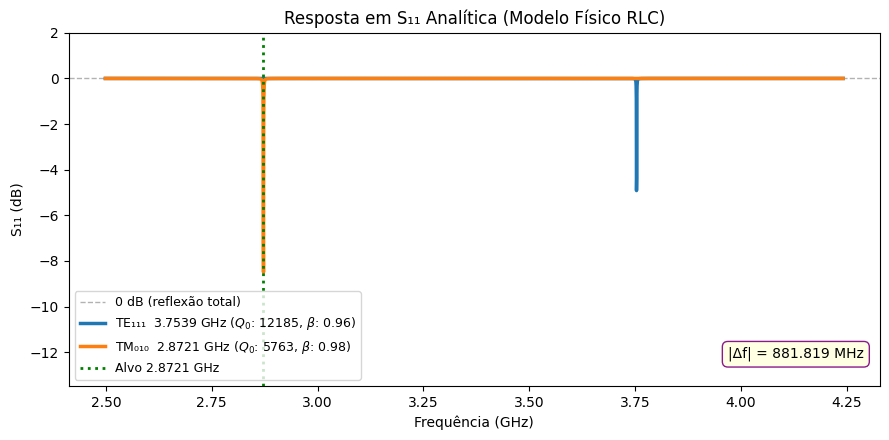

In [29]:
# 1. Calculando as frequências exatas usando a classe
fte_val = cavidade_elip.freq_ressonancia(m=1, n=1, p=1, tipo_modo='TE')
ftm_val = cavidade_elip.freq_ressonancia(m=0, n=1, p=0, tipo_modo='TM')

df = abs(fte_val - ftm_val) / 1e6  # Diferença em MHz
TARGET = ftm_val / 1e9             # Alvo em GHz

# =====================================================================
# 2. CÁLCULO ANALÍTICO DO FATOR DE QUALIDADE (Q0)
# =====================================================================
sigma_metal = 5.8e7  # Condutividade do Cobre (S/m)
mu_0 = sc.mu_0

def calc_skin_depth(freq):
    return np.sqrt(2 / (2 * np.pi * freq * mu_0 * sigma_metal))

R_eq = (cavidade_elip.a + cavidade_elip.b) / 2.0
d_m = cavidade_elip.d

# Fator Q para o Modo TM010
delta_tm = calc_skin_depth(ftm_val)
Q_TM_calc = R_eq / (delta_tm * (1 + R_eq / d_m))

# Fator Q para o Modo TE111
delta_te = calc_skin_depth(fte_val)
p11 = 1.841 
x = (np.pi * R_eq) / d_m
numerador_te = (1 - (1 / p11**2)) * (p11**2 + x**2)**(3/2)
denominador_te = p11**2 + (2 * R_eq / d_m) * x**2 + (1 - (1 / p11**2)) * x**2 * (2 * R_eq / d_m)
Q_TE_calc = (R_eq / delta_te) * (numerador_te / denominador_te)

# =====================================================================
# 3. MODELO FÍSICO DO S11 E ACOPLAMENTO (BETA)
# =====================================================================
# Defina o nível de acoplamento da sua antena (beta = 1.0 é o casamento perfeito)
beta_TE = 0.96  # Ligeiramente sub-acoplado
beta_TM = 0.98  # Muito próximo do crítico

def calcular_S11_fisico(f_array_ghz, f0_hz, Q0, beta):
    """Equação física real da reflexão |Gamma(f)| para uma cavidade acoplada."""
    f0_ghz = f0_hz / 1e9
    delta_f = (f_array_ghz - f0_ghz) / f0_ghz
    
    # Numerador e Denominador da impedância da cavidade
    num = (1 - beta)**2 + (2 * Q0 * delta_f)**2
    den = (1 + beta)**2 + (2 * Q0 * delta_f)**2
    
    gamma_mag = np.sqrt(num / den)
    
    # Limita o valor mínimo para não dar erro no log10 caso beta seja exatamente 1.0
    gamma_mag = np.maximum(gamma_mag, 1e-6) 
    return 20 * np.log10(gamma_mag)

# Eixo de frequências
flo = (min(fte_val, ftm_val) / 1e9) * 0.87
fhi = (max(fte_val, ftm_val) / 1e9) * 1.13
f_ghz = np.linspace(flo, fhi, 4000)

S11_TE = calcular_S11_fisico(f_ghz, fte_val, Q_TE_calc, beta_TE)
S11_TM = calcular_S11_fisico(f_ghz, ftm_val, Q_TM_calc, beta_TM)

# Profundidades exatas calculadas no pico (apenas para exibição no gráfico)
prof_TE = np.min(S11_TE)
prof_TM = np.min(S11_TM)

# =====================================================================
# 4. PLOTAGEM
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='grey', lw=1.0, ls='--', alpha=0.6, label='0 dB (reflexão total)')

ax.plot(f_ghz, S11_TE, lw=2.5, label=f'TE₁₁₁  {fte_val/1e9:.4f} GHz ($Q_0$: {int(Q_TE_calc)}, $\\beta$: {beta_TE})')
ax.plot(f_ghz, S11_TM, lw=2.5, label=f'TM₀₁₀  {ftm_val/1e9:.4f} GHz ($Q_0$: {int(Q_TM_calc)}, $\\beta$: {beta_TM})')
ax.axvline(TARGET, color='green', ls=':', lw=2.0, label=f'Alvo {TARGET:.4f} GHz')

ax.annotate(
    f'|Δf| = {df:.3f} MHz',
    xy=(0.98, 0.07), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='purple', alpha=0.9)
)

ax.set_ylim(min(prof_TE, prof_TM) - 5, 2)
ax.set_xlabel('Frequência (GHz)')
ax.set_ylabel('S₁₁ (dB)')
ax.set_title('Resposta em S₁₁ Analítica (Modelo Físico RLC)')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

## 1.5 Varredura da altura $L$ (Degenerescência de Modos)

Esta etapa mostra como a altura da cavidade ($d$) altera a frequência do modo TE₁₁₁ e permite localizar o ponto de degenerescência com o modo TM₀₁₀.

O objetivo é encontrar a altura exata em que as duas curvas se cruzam, o que é vital para alinhar ressonâncias em experimentos físicos (como a sintonia do MASER).

Calculando varredura de altura L... aguarde um instante.


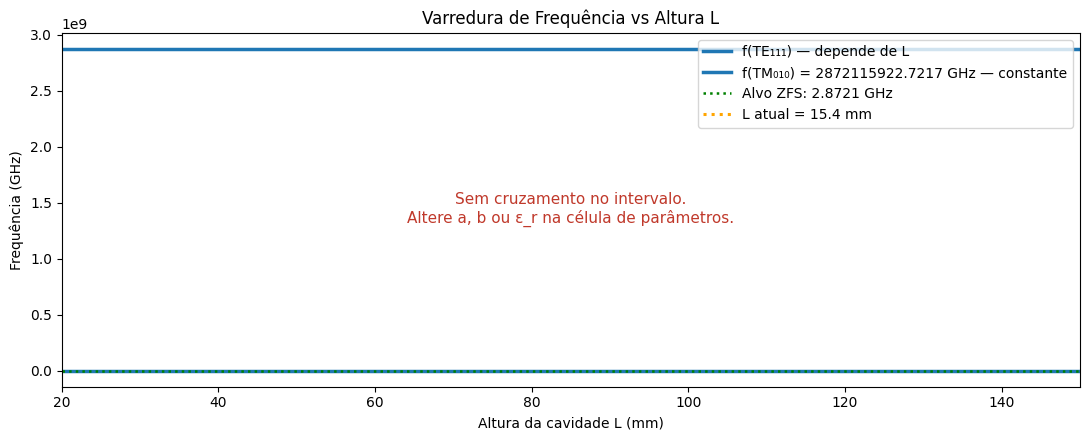

In [30]:
# 1. Funções auxiliares para recalcular a frequência variando apenas L
def fTE_var_L(L_mm):
    """Cria uma instância temporária da cavidade para uma nova altura L e retorna f(TE111)."""
    cav_temp = CavidadeEliptica3D(a=a_mm * sc.milli, b=b_mm * sc.milli, d=L_mm * sc.milli, er=er_val)
    return cav_temp.freq_ressonancia(m=1, n=1, p=1, tipo_modo='TE') / 1e9

# TM010 é independente de L, então é constante
ftmC = ftm_val 

# 2. Varredura
L_START = 20.0
L_MAX = max(150.0, d_mm * 2.5)
Ls = np.linspace(L_START, L_MAX, 80) # 80 pontos para otimizar o tempo de simulação do solver

print("Calculando varredura de altura L... aguarde um instante.")
fTEs_scan = [fTE_var_L(l) for l in Ls]
fTE_cur = fTE_var_L(d_mm)

# 3. Busca do Cruzamento (Bisseção)
def func_cross(L_mm):
    return fTE_var_L(L_mm) - ftmC

try:
    # Procura a raiz (onde fTE - fTM == 0) no intervalo
    Lc = opt.brentq(func_cross, L_START, L_MAX)
    cross = {'L': Lc, 'f': ftmC}
except ValueError:
    cross = None # Se as curvas não se cruzarem no intervalo

# 4. Plotagem
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(Ls, fTEs_scan, lw=2.5, label='f(TE₁₁₁) — depende de L')
ax.axhline(ftmC, lw=2.5, label=f'f(TM₀₁₀) = {ftmC:.4f} GHz — constante')
ax.axhline(TARGET, color='green', ls=':', lw=1.8, label=f'Alvo ZFS: {TARGET:.4f} GHz')

if cross:
    Lc_val, fc_val = cross['L'], cross['f']
    ax.plot(Lc_val, fc_val, 'o', ms=10, zorder=8, label=f'L ideal = {Lc_val:.2f} mm')
    ax.annotate(
        f'✓ Cruzamento\nL = {Lc_val:.2f} mm',
        xy=(Lc_val, fc_val), xytext=(Lc_val + 5, fc_val + 0.2),
        arrowprops=dict(arrowstyle='->', lw=2.0),
        bbox=dict(boxstyle='round,pad=0.5', fc='#EAFAF1', ec='#27AE60', lw=1.5)
    )
else:
    ax.text(
        0.5, 0.5,
        'Sem cruzamento no intervalo.\nAltere a, b ou ε_r na célula de parâmetros.',
        transform=ax.transAxes, ha='center', va='center', fontsize=11, color='#C0392B'
    )

ax.axvline(d_mm, color='orange', ls=':', lw=2.2, label=f'L atual = {d_mm:.1f} mm')
ax.plot(d_mm, fTE_cur, 's', color='orange', ms=10, zorder=7)

ax.set_xlim(L_START, L_MAX)
ax.set_xlabel('Altura da cavidade L (mm)')
ax.set_ylabel('Frequência (GHz)')
ax.set_title('Varredura de Frequência vs Altura L')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()